
                                Data Loaded Successfully!
                                
                                      First 10 rows                                       
  Student_Name                                       College_Name  \
0        Aarav        Indian Institute of Information Technology    
1       Vivaan    Government Ram Bhajan Rai NES College, Jashpur    
2       Aditya      Dolphin PG Institute of BioMedical & Natural    
3       Vihaan   Shaheed Rajguru College of Applied Sciences for    
4        Arjun                    Roorkee College of Engineering    
5          Sai                               Kanya Mahavidyalaya    
6      Reyansh      Shivalik Institute of Paramedical Technology    
7        Ayaan  Alpha College of Engineering & Technology, Pon...   
8      Krishna  Jaipur Engineering College and Research Centre...   
9       Ishaan                        ICFAI University, Shillong    

        Stream  Year_of_Study             AI_Tools_Used  

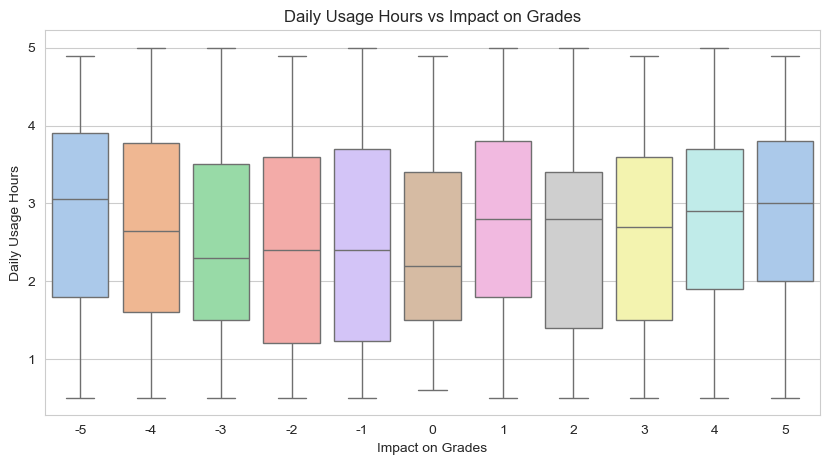

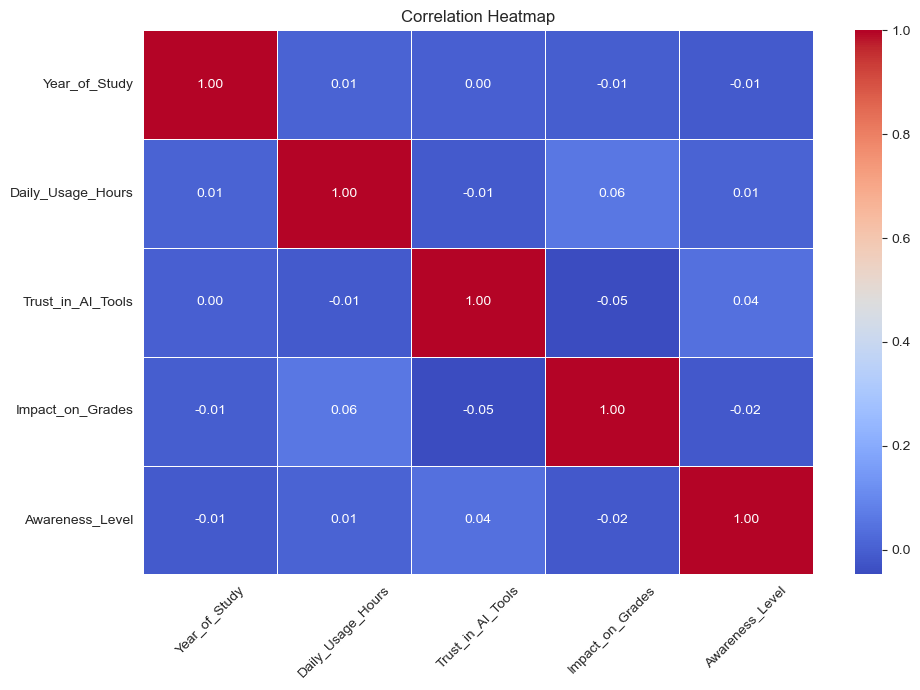

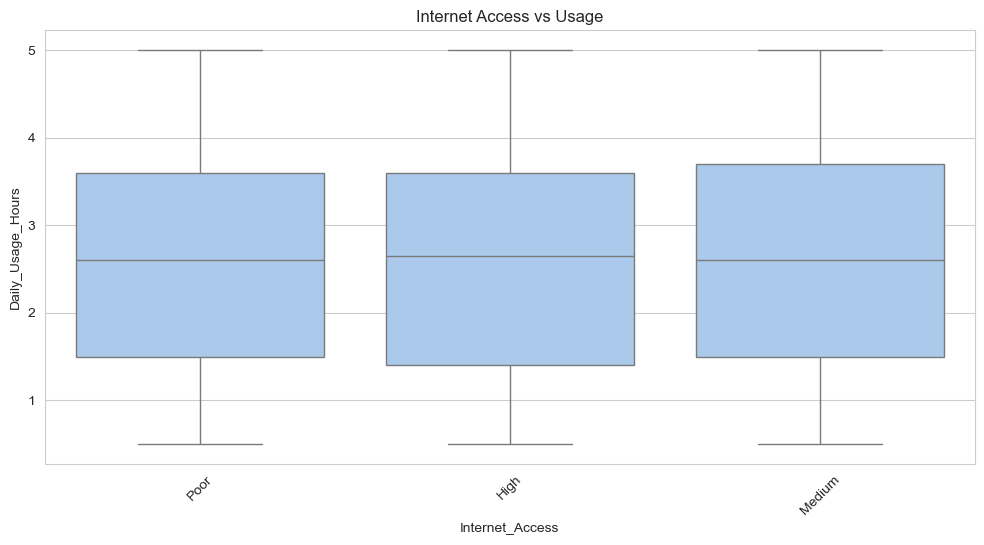

Stream
Agriculture         2.651908
Arts                2.699516
Commerce            2.733242
Engineering         2.245545
Hotel-management    2.419811
Law                 2.658130
Management          2.456316
Medical             2.438790
Pharmacy            2.744048
Science             2.661889
Name: Daily_Usage_Hours, dtype: float64


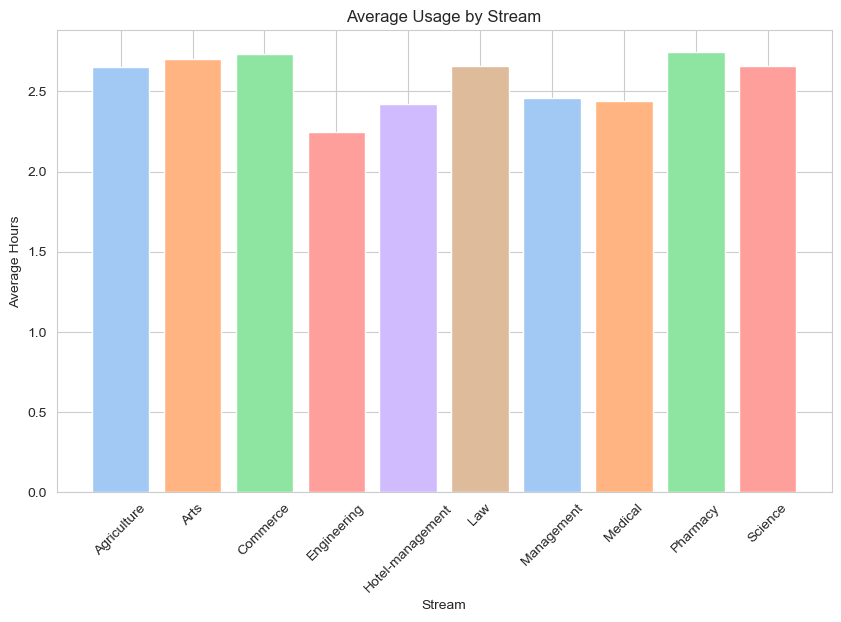

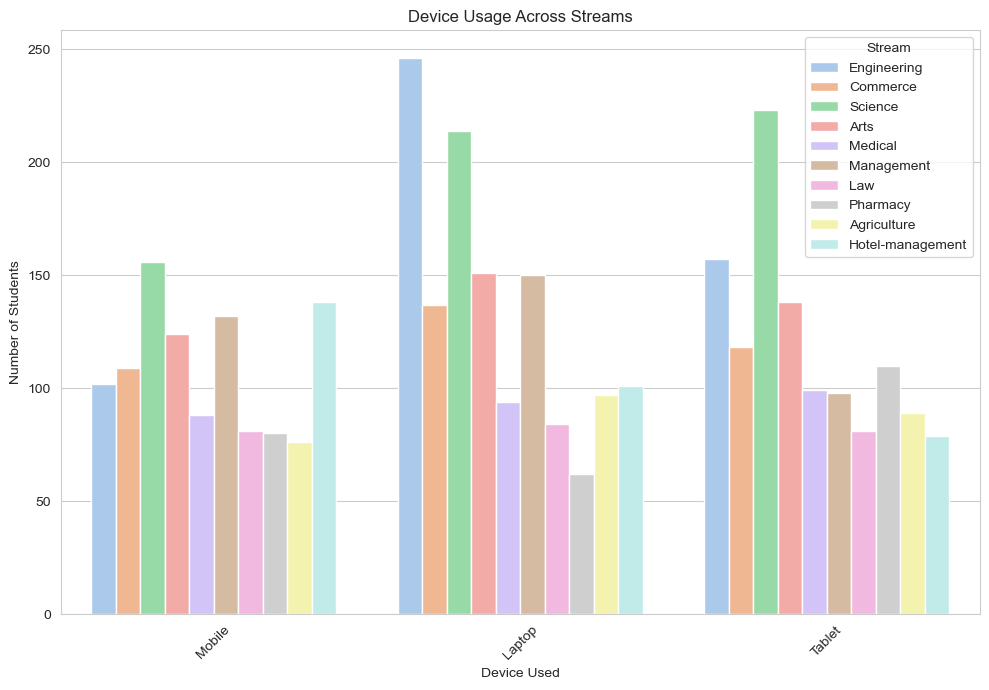

Average Usage of AI in daily life of students 2.5596845600442726


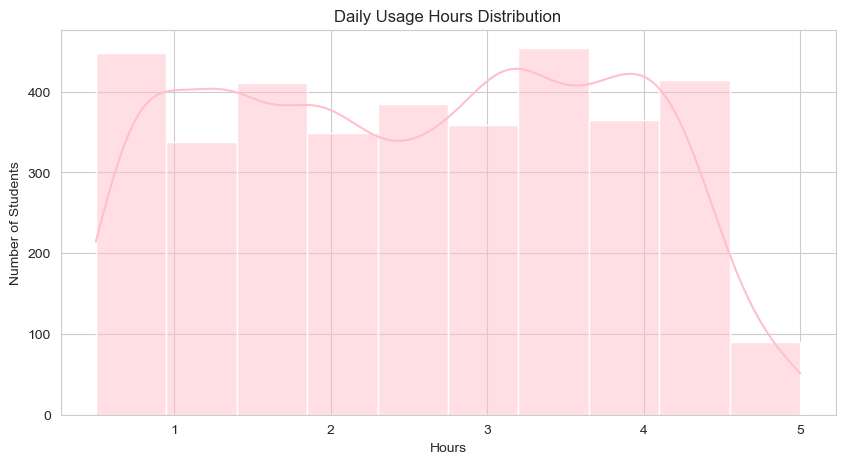

Preferred_AI_Tool
ChatGPT    859
Gemini     854
Copilot    836
Other      757
Claude     157
Bard       151
Name: count, dtype: int64


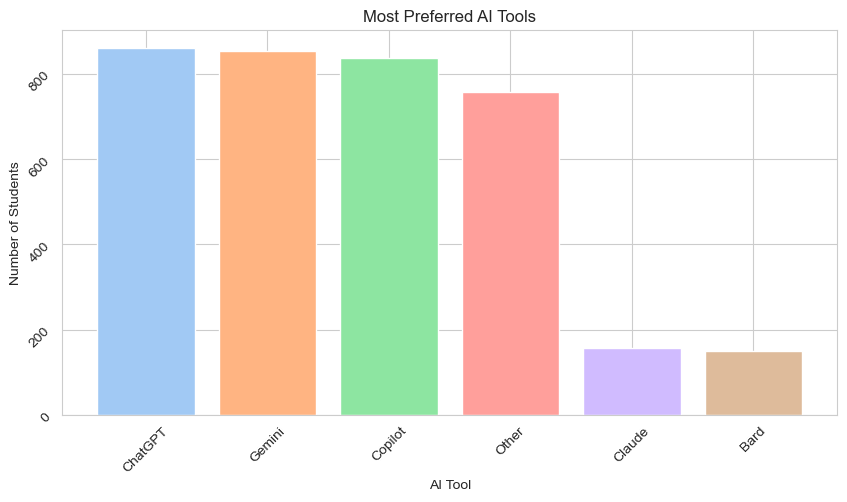

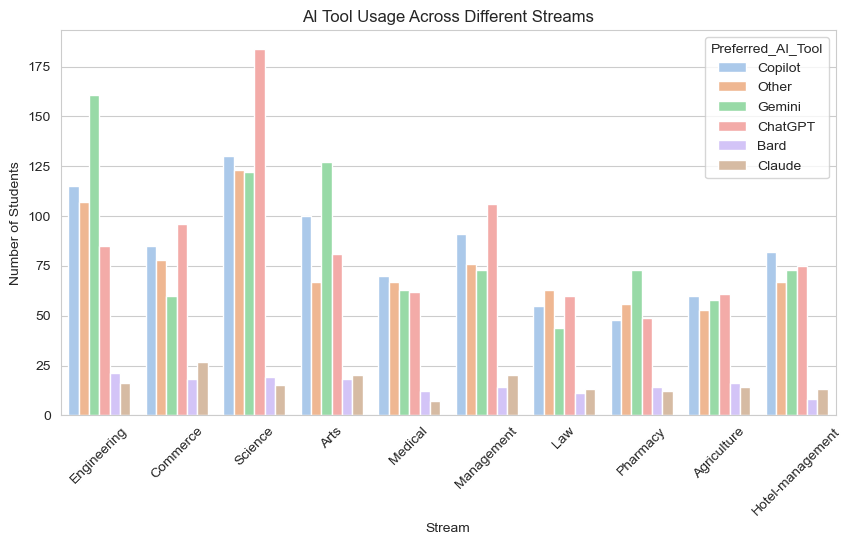

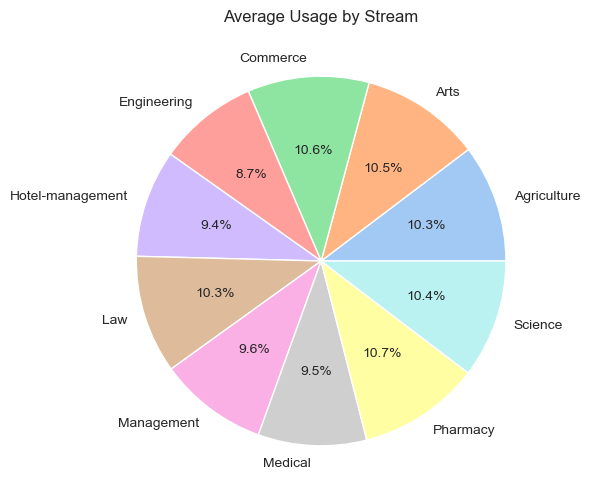

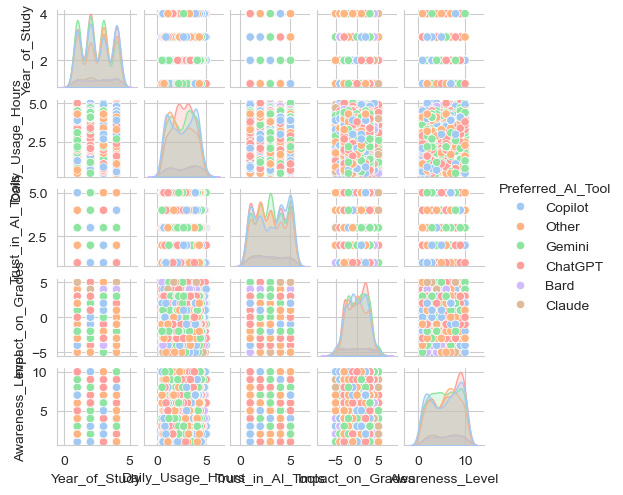

1st Objective
Slope: 0.11180670820241241
Intercept: -0.2828694841084827
R-value: 0.057222287409585605
P-value: 0.0005782060938833707
Predicted Impact for 5 hours: 0.2761640569035793

There is a positive relationship (more usage → better grades)
The relationship is weak
Relationship is statistically significant
Predicted impact is positive for 5 hours usage
2nd Objective
Correlation Matrix:
                    Year_of_Study  Daily_Usage_Hours  Trust_in_AI_Tools  \
Year_of_Study           1.000000           0.007906           0.000744   
Daily_Usage_Hours       0.007906           1.000000          -0.012369   
Trust_in_AI_Tools       0.000744          -0.012369           1.000000   
Impact_on_Grades       -0.005867           0.057222          -0.047310   
Awareness_Level        -0.012708           0.005981           0.039466   

                   Impact_on_Grades  Awareness_Level  
Year_of_Study             -0.005867        -0.012708  
Daily_Usage_Hours          0.057222         0.00598

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv("Students.csv")
df.columns = df.columns.str.strip()
print("\n" + "=" * 90)
print("Data Loaded Successfully!\n".center(90))

print( "=" * 90)
print("First 10 rows".center(90))
print("=" * 90)
print( df.head(10), "\n")

print("\n" + "=" * 90)
print("Last 10 rows".center(90))
print("=" * 90)
print( df.tail(10), "\n")


print("=" *90)
print("Dataframe Info:".center(90))
print("=" *90)
df.info()
print("\n")

print("Shape:" , df.shape)

print("Columns:" , df.columns)
print("\n")

print("=" *90)
print("Statistical summary of all columns".center(90))
print("=" *90)
print(df.describe(include='all'))


print("=" *90)
print("Missing values:".center(90))
print("=" *90)
print(df.isnull().sum())

# Fill missing values
# ffill isused for forward fill
df_filled = df.ffill()

# Remove duplicates
df_cleaned = df_filled.drop_duplicates()

# # data after cleaning
print("Data after cleaning:\n", df_cleaned.head())
print("=" *90)
print("Missing value after applying forward fill:".center(90))
print("=" *90)
print(df_cleaned.isnull().sum())


# Quantitative Exploratory Data Analysis (EDA)
# Descriptive statistics
print("=" * 90)
print("Descriptive Statistics:".center(90))
print("="*90)
print(df_cleaned.describe())

# Correlation (only numeric)
numeric_df = df_cleaned.select_dtypes(include=[np.number])
print("=" * 90)
print("Correlation Matrix:".center(90))
print("=" * 90)
print(numeric_df.corr())

# Covariance
print("=" * 90)
print("Covariance Matrix:".center(90))
print("=" * 90)
print(numeric_df.cov())




# Statistical Analysis USING IQR
# OUTLIER DETECTION IN DAILY_USAGE_HOURS

data = df_cleaned['Daily_Usage_Hours']
Q1 = np.percentile(data, 25)
Q3 = np.percentile(data, 75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = data[(data < lower_bound) | (data > upper_bound)]

# Check if outliers exist
if outliers.empty:
    print("No outliers detected . No student have unusually high or low daily usage of AI tools")
else:
    print("Outliers:\n", outliers)




# Visualization 
# 1st  ("Daily Usage Hours vs Impact on Grades")

print("\n")
print("=" *90)
print("VISUALISATION STARTS".center(90))
print("=" *90, "\n")
print("\n")

sns.set_style("whitegrid")
sns.set_palette("pastel")


plt.figure(figsize=(10,5))
sns.boxplot(
    x="Impact_on_Grades",
    y="Daily_Usage_Hours",
    data=df_cleaned,
    hue="Impact_on_Grades",
    legend=False,
    palette="pastel",
)

plt.title("Daily Usage Hours vs Impact on Grades")
plt.xlabel("Impact on Grades")
plt.ylabel("Daily Usage Hours")
plt.show()

# 2> CORRELATION

corr = numeric_df.corr()
plt.figure(figsize=(10,7))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()   # prevents label cutting
plt.show()

# 3> "Internet Access vs Usage"

plt.figure(figsize=(10,5))
plt.xticks(rotation=45)  
plt.tight_layout()
sns.boxplot(x="Internet_Access", y="Daily_Usage_Hours", data = df_cleaned)
plt.title("Internet Access vs Usage")
plt.show()

# 4>  Average Usage by Stream(using bar grap)

# Group data
stream_usage = df_cleaned.groupby('Stream')['Daily_Usage_Hours'].mean()
print(stream_usage)

# Plot
plt.figure(figsize=(10,6))
plt.bar(stream_usage.index, stream_usage.values, color=colors)

plt.title("Average Usage by Stream")
plt.xlabel("Stream")
plt.ylabel("Average Hours")
plt.xticks(rotation=45)

plt.show()

# 5> Device most commonly used for AI tools in each stream

plt.figure(figsize=(10,7))  

sns.countplot(
    x='Device_Used',
    hue='Stream',
    data=df_cleaned,
)

plt.title("Device Usage Across Streams")
plt.xlabel("Device Used")
plt.ylabel("Number of Students")
plt.xticks(rotation=45)

plt.legend(title="Stream", loc='upper right')   # fixed (inside)

plt.tight_layout()
plt.show()

# 6> How many hours do students spend daily on AI tools?

# pastel palette
plt.figure(figsize=(10,5))

# Calculate average usage
avg_usage = df_cleaned['Daily_Usage_Hours'].mean()
print("="* 90)
print("Average Usage of AI in daily life of students", avg_usage)
print("="* 90)

sns.histplot(df_cleaned['Daily_Usage_Hours'], bins=10, kde=True, color='pink')

plt.title("Daily Usage Hours Distribution")
plt.xlabel("Hours")
plt.ylabel("Number of Students")
plt.show()

# 7> Which AI tool is most preferred by students?

plt.figure(figsize=(10,5))

tool_count = df_cleaned['Preferred_AI_Tool'].value_counts()
print(tool_count)

# bar chart with different colors
plt.bar(tool_count.index, tool_count.values, color=colors)

plt.title("Most Preferred AI Tools")
plt.xlabel("AI Tool")
plt.ylabel("Number of Students")
plt.yticks(rotation=45)
plt.xticks(rotation=45)
plt.show()

# 8> Which AI tool is used the most across different streams?
# Set pastel theme

plt.figure(figsize=(10,5))
sns.countplot(x='Stream', hue='Preferred_AI_Tool', data=df_cleaned)

plt.title("AI Tool Usage Across Different Streams")
plt.xlabel("Stream")
plt.ylabel("Number of Students")
plt.xticks(rotation=45)
plt.show()

# 9>What is the proportion of average daily AI usage among different academic streams? (by pie chart)

# Plot Pie Chart
plt.figure(figsize=(7,6))
plt.pie(
    stream_usage.values,
    labels=stream_usage.index,
    autopct='%1.1f%%'
)

plt.title("Average Usage by Stream")
plt.show()

# 10 Overall  
sns.pairplot(df_cleaned, hue='Preferred_AI_Tool', height=1)
plt.show()

#  OBJECTIVE 1: LINEAR REGRESSION 
# Does the amount of time students spend using AI tools significantly affect their academic performance?

print("="*90)
print("1st Objective")
print("="*90)

# Prepare data
df_lr = df_cleaned[['Daily_Usage_Hours', 'Impact_on_Grades']].dropna()
df_lr['Daily_Usage_Hours'] = pd.to_numeric(df_lr['Daily_Usage_Hours'], errors='coerce')
df_lr['Impact_on_Grades'] = pd.to_numeric(df_lr['Impact_on_Grades'], errors='coerce')
df_lr = df_lr.dropna()

# definig variable
x = df_lr['Daily_Usage_Hours']
y = df_lr['Impact_on_Grades']

# Linear Regression
slope, intercept, r, p, std_err = stats.linregress(x, y)

# Example prediction (for 5 hours of usage)
predicted = slope * 5 + intercept

print("Slope:", slope)
print("Intercept:", intercept)
print("R-value:", r)
print("P-value:", p)
print("Predicted Impact for 5 hours:", predicted)


#Relationship direction
if slope > 0:
    print("\nThere is a positive relationship (more usage → better grades)")
elif slope < 0:
    print("\nThere is a negative relationship (more usage → lower grades)")
else:
    print("\nNo clear relationship between usage and grades")

# Strength of correlation
if abs(r) > 0.7:
    print("The relationship is strong")
elif abs(r) > 0.3:
    print("The relationship is moderate")
else:
    print("The relationship is weak")


# Significance test
alpha = 0.05
if p < alpha:
    print("Relationship is statistically significant")
else:
    print("Relationship is not statistically significant")

#Prediction interpretation
if predicted > 0:
    print("Predicted impact is positive for 5 hours usage")
elif predicted < 0:
    print("Predicted impact is negative for 5 hours usage")
else:
    print("Predicted impact is neutral")

#  OBJECTIVE 2: CORRELATION 
# how numerical variables are related to each other, 'Daily_Usage_Hours' vs 'Impact_on_Grades'.

print("="*90)
print("2nd Objective")
print("="*90)

# Correlation matrix
corr = numeric_df.corr()
print("Correlation Matrix:\n", corr)

# Focus on relationship between usage and grades
value = corr.loc['Daily_Usage_Hours', 'Impact_on_Grades']

print("\nCorrelation between Usage and Impact:", value)

if value > 0.7:
    print("Strong positive relationship (more usage → higher grades)")
elif value > 0.3:
    print("Moderate positive relationship")
elif value > 0:
    print("Weak positive relationship")
elif value == 0:
    print("No relationship found")
elif value > -0.3:
    print("Weak negative relationship")
elif value > -0.7:
    print("Moderate negative relationship")
else:
    print("Strong negative relationship (more usage → lower grades)")

# OBJECTIVE 3: HYPOTHESIS TESTING (Z-TEST)
# A university wants to verify whether students with better internet access actually spend more time using AI tools than those with poor access.

print("="*90)
print("3rd Objective : Internet Access vs AI Usage")
print("="*90)

high = df_cleaned[df_cleaned['Internet_Access'] == 'High']['Daily_Usage_Hours']
low = df_cleaned[df_cleaned['Internet_Access'] == 'Poor']['Daily_Usage_Hours']

mean1, mean2 = np.mean(high), np.mean(low)
std1, std2 = np.std(high), np.std(low)

n1, n2 = len(high), len(low)

# Z-test calculation
z = (mean1 - mean2) / np.sqrt((std1**2 / n1) + (std2**2 / n2))
p_value = 1 - stats.norm.cdf(z)

print("Z-Score:", z)
print("P-Value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("Reject H0: Students with high internet access spend more time on AI tools.")
else:
    print("Fail to Reject H0: No significant difference found between the two groups.")


# OBJECTIVE 4: Z-TEST (Device Comparison)
# A university wants to verify whether students using laptopsspend more time on AI tools than those using mobile devices.

print("="*90)
print("4th Objective")
print("="*90)

laptop = df_cleaned[df_cleaned['Device_Used'] == 'Laptop']['Daily_Usage_Hours']
mobile = df_cleaned[df_cleaned['Device_Used'] == 'Mobile']['Daily_Usage_Hours']

mean1, mean2 = np.mean(laptop), np.mean(mobile)
std1, std2 = np.std(laptop), np.std(mobile)

n1, n2 = len(laptop), len(mobile)

z = (mean1 - mean2) / np.sqrt((std1**2 / n1) + (std2**2 / n2))
p_value = 1 - stats.norm.cdf(z)

print("Z-Score:", z)
print("P-Value:", p_value)

# P-value
alpha = 0.05
if p_value < alpha:
    print("Laptop users spend significantly more time on AI tools.")
else:
    print("No significant difference between laptop and mobile users.")

# OBJECTIVE 5: SIMPLE LINEAR REGRESSION (CORRECTED)
# Does Trust in AI Tools predict Awareness Level?

print("="*90)
print("5th Objective")
print("="*90)

# Convert to numeric
df_cleaned['Trust_in_AI_Tools'] = pd.to_numeric(df_cleaned['Trust_in_AI_Tools'], errors='coerce')
df_cleaned['Awareness_Level'] = pd.to_numeric(df_cleaned['Awareness_Level'], errors='coerce')
df_lr = df_cleaned[['Trust_in_AI_Tools', 'Awareness_Level']].dropna()

# Variables
x = df_lr['Trust_in_AI_Tools']
y = df_lr['Awareness_Level']

# Linear regression
slope, intercept, r, p, std_err = stats.linregress(x, y)

# Prediction ( trust = 4)
predicted = slope * 4 + intercept

# Output
print(f"Slope: {slope}")
print(f"Intercept: {intercept}")
print(f"Correlation (r): {r}")
print(f"P-value: {p}")
print(f"Predicted Awareness (Trust = 4): {predicted}")
print("\n")

if slope > 0:
    print("Positive relationship. Higher trust → Higher awareness")
elif slope < 0:
    print("Negative relationship . As trust increases, awareness decreases")
else:
    print("No relationship")
# Strength of relationship
if abs(r) > 0.3:
    print("Moderate to strong relationship")
else:
    print("Weak relationship")
# Statistical significance
if p < 0.05:
    print("Relation is Statistically significant")
else:
    print("Relation is not statistically significant")
print("\n")